In [1]:
%%HTML
    
<!-- reveal.js CSS theme and local overrides -->
<link rel="styl
sheet" href="https://fonts.googleapis.com/css?family=Open+Sans:300,400,600,700&amp;lang=en"/>
<link rel="stylesheet" href="https://fonts.googleapis.com/css?family=Merriweather:italic&amp;lang=en"/>
<link rel="stylesheet" href="presentation.css"/>  

In [2]:
import pandas as pd
import os
from datetime import date
import markdown
from IPython.display import HTML

# Set information:
event = 'Vorlesung_03_Balken_FEM'
title = 'FEM für Strukturelemente'
subtitle = 'Finite Elementformulierung für den Bernoullibalken'
module = "Einführung in die FEM"
today = date.today().strftime('%d-%m-%Y')
datum = "Wintersemester 2025/2026"

# presenter information:
name = 'Prof. Dr. Steffen Beese'
email = 'steffen.beese@eah-jena.de'
url = 'https://www.eah-jena.de/mb/fachbereich/professoren/prof-dr-steffen-beese'

In [3]:
# set HTMLs
email_html = HTML(f"<a href='mailto:{email}'>{email}</a>")
url_html = HTML(f"<a href='{url}'>{url}</a>")
footer_html = HTML(f"<div class='footer'>{event} | {title} | {today}</div>")

# This line will add a button to toggle visibility of code blocks,
# for use with the HTML export version
toggle = HTML('''<button style="margin:0 auto; display: block;" onclick="jQuery('.code_cell .input_area').toggle();
    jQuery('.prompt').toggle();">Toggle code</button>''')
toggle

<section id="title-slide"> 
    <div id='rise-header'><img id="logo" src="./images/logo.jpeg"></div>
    <br><br><br><h1><i>FEM für Strukturelemente</i></h1>
    <h4><i>Finite Elementformulierung für den Bernoullibalken</i></h4>
    <br><br><br><br><br><br>
    <div class="uu_title_container">
        <smaller>
        <div class='column'>
            <b>Presented by:</b><br>Prof. Dr. Steffen Beese
        </div>  
        <div class='column'>
            <b>Modul: </b><br> Einführung in die FEM<sup>
    </div><br>
    <div class='footer'>
        Wintersemester 2025/2026 | Ernst-Abbbe-Hochschule Jena
    </div>
</section>

# Inhaltsverzeichnis

1. Theorie der Balkenbiegung
2. Schwache Formulierung für den Balken
3. Ansatz für das Verschiebungsfeld
4. Herleitung der Steifigkeitsmatrix
5. Beispiel: Balken unter Streckenlast

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Theorie der Balkenbiegung

<div style="display: flex; align-items: flex-start;">
  <figure style="margin: 0; text-align: center;">
    <img src="images/Balken_TM2.png" alt="BalkenTheorie" width="300" style="height: auto;">
    <figcaption style="font-style: italic; font-size: 0.9em; margin-top: 4px;">
      Kinematik der Balkendeformation nach: Gross, D., Hauger, W., Schröder, J., & Wall, W. A. (2007). 
      <em>Technische Mechanik: Band 2: Elastostatik</em>. Springer.
    </figcaption>
  </figure>
  
  <div style="margin-left: 20px;">
    <ul>
      <li>Grundlage für das Balkenelement ist die Bernoulli-Balken Theorie</li>
      <li>Verformungen bleiben klein (lineare Theorie)</li>
      <li>Querschnitte bleiben eben und rechtwinklig zur Balkenachse</li>
    </ul>
  </div>
</div>


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Beschreibende Differentialgleichung und schwache Form

Die Differentialgleichung für die Durchbiegung $w$ eines Balkens mit konstanter Biegesteifigkeit $EI$ lautet:

$$
EI w^{IV} = q_0
$$

Die schwache Form der Differentialgleichung wurde in der Vorlesung besprochen und lautet:

$$
 \underbrace{EI_y \int_L \delta w'' w'' \text{ dx}}_{\text{innere Arbeit}} - \underbrace{\int_L q(x) \delta w \text{ dx}}_{\text{Arbeit der Streckenlast}} - \underbrace{F_I \delta w_I - M_J \delta w'_J }_{\text{Arbeit der äußeren Lasten}}= 0 \; .
$$

<div style="border-left: 4px solid #1E90FF; background-color: #F0F8FF; padding: 10px; margin: 10px 0;">
  <strong>ℹ️ schwache Form</strong>
  <p>Auch hier ist die Ordnung der Ableitung in der schwachen Form niedriger.</p>
</div>

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Das Balkenelement

![Balkenelement](images/Balkenelement.png)

Ziel ist es, die schwache Form der Differentialgleichung in ein algebraisches Gleichungssystem umzuwandeln:

$$
\boldsymbol{K} \boldsymbol{w} = \boldsymbol{F}_Q + \boldsymbol{F} + \boldsymbol{M}
$$

Hierbei hat der Vektor $\boldsymbol{F}$ der äußeren angreifenden Lasten nur Einträge an den Stellen, die mit den Durchbiegungen verknüpft sind. Der Vektor $\boldsymbol{M}$ hat hingegen nur Einträge an den Stellen, die mit den Neigungen verknüpft sind.

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Verschiebungsansatz

Analog zum Stabelement führen wir die normierte Koordinate $\xi=\frac{x}{\ell_e}$ ein. Die Ansatzfunktionen für die Durchbiegung $w_h$ wird dann als Linearkombination der Formfunktionen $N_I$ und der Freiheitsgrade $\hat{w}_I$ geschrieben: 
$$
w_h = \sum_{I=1}^{6} N_I \hat{w}_I
$$

Als Formfunktionen $N_I$ werden die Hermite-Polynome verwendet. Diese lauten:

$$
\begin{align}
  N_1 &= 1-3\xi^2+2\xi^3 \\ 
  N_2 &= (\xi-2\xi^2+\xi^3)\ell_e \\ 
  N_3 &= 3\xi^2-2\xi^3 \\ 
  N_4 &= (-\xi^2+\xi^3)\ell_e
\end{align}
$$

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

In [4]:
toggle

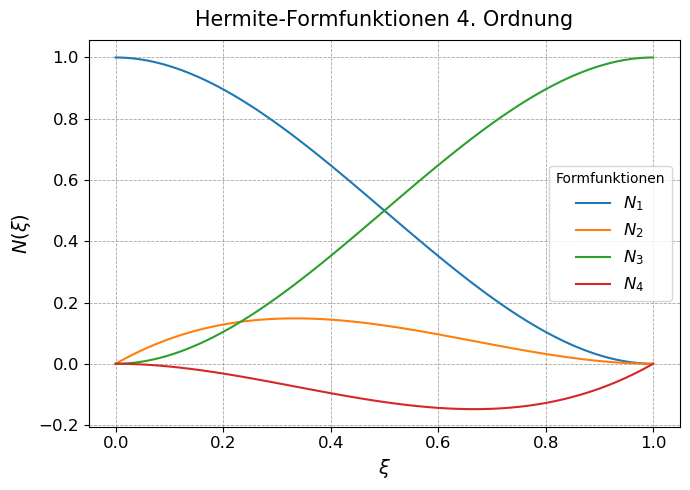

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Daten definieren
x = np.linspace(0, 1, 100)

# Hermite-Formfunktionen 4. Ordnung
N1 = 1 - 3*x**2 + 2*x**3
N2 = x - 2*x**2 + x**3
N3 = 3*x**2 - 2*x**3
N4 = -x**2 + x**3

N = N1+N2+N3+N4

# Figur und Achsenobjekt erstellen
fig, ax = plt.subplots(figsize=(7, 5))

# Formfunktionen plotten
ax.plot(x, N1, label=r"$N_1$")
ax.plot(x, N2, label=r"$N_2$")
ax.plot(x, N3, label=r"$N_3$")
ax.plot(x, N4, label=r"$N_4$")

# Achsenbeschriftungen, Titel und Legende
ax.set_xlabel(r"$\xi$", fontsize=14)
ax.set_ylabel(r"$N(\xi)$", fontsize=14)
ax.set_title("Hermite-Formfunktionen 4. Ordnung", fontsize=15, pad=10)
ax.legend(title="Formfunktionen", fontsize=12)

# Gitter und Stil
ax.grid(True, color='grey', linewidth=0.6, linestyle='--', alpha=0.7)
ax.tick_params(labelsize=12)

# Layout anpassen und Plot anzeigen
fig.tight_layout()
plt.show()

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Eigenschaften der Formfunktionen

- Großer Vorteil der FEM: die Knotenfreiheitsgrade entsprechen physikalischen Größen (hier: Durchbiegung):
$$
w_h = \sum_{I=1}^{6} N_I \hat{w}_I
$$
- Wenn die Koordinate $\xi$ den Wert 1 hat (Wir befinden uns an Knoten 2):
  - Nur $N_2$ ist 1, die anderen haben den Wert 0
  - Nur $\hat{w}_2$ liefert Beitrag zu $w_h$
  - Deshalb ist $\hat{w}_2 = w_h$ für $\xi = 1$
- Die Summe der Formfunktionen ist immer gleich 1 (warum dies so ist, erfahren wir später)

In [6]:
toggle

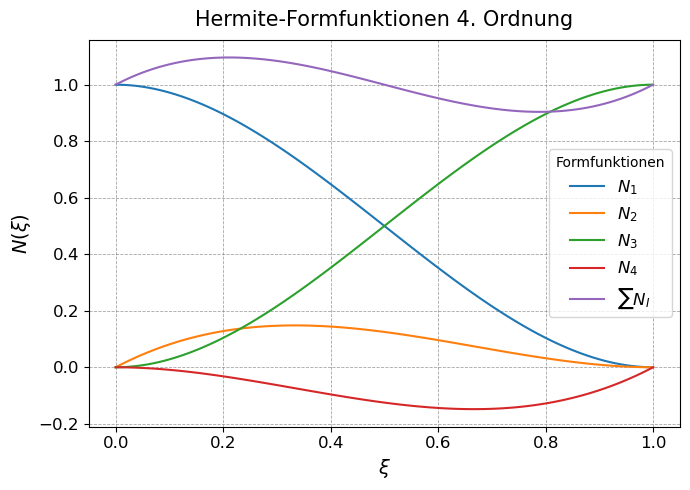

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Daten definieren
x = np.linspace(0, 1, 100)

# Hermite-Formfunktionen 4. Ordnung
N1 = 1 - 3*x**2 + 2*x**3
N2 = x - 2*x**2 + x**3
N3 = 3*x**2 - 2*x**3
N4 = -x**2 + x**3

N = N1+N2+N3+N4

# Figur und Achsenobjekt erstellen
fig, ax = plt.subplots(figsize=(7, 5))

# Formfunktionen plotten
ax.plot(x, N1, label=r"$N_1$")
ax.plot(x, N2, label=r"$N_2$")
ax.plot(x, N3, label=r"$N_3$")
ax.plot(x, N4, label=r"$N_4$")
ax.plot(x,N, label=r'$\sum N_I$')

# Achsenbeschriftungen, Titel und Legende
ax.set_xlabel(r"$\xi$", fontsize=14)
ax.set_ylabel(r"$N(\xi)$", fontsize=14)
ax.set_title("Hermite-Formfunktionen 4. Ordnung", fontsize=15, pad=10)
ax.legend(title="Formfunktionen", fontsize=12)

# Gitter und Stil
ax.grid(True, color='grey', linewidth=0.6, linestyle='--', alpha=0.7)
ax.tick_params(labelsize=12)

# Layout anpassen und Plot anzeigen
fig.tight_layout()
plt.show()

### Element-Steifigkeitsmatrix für ein Balkenelemt

$$
\begin{align*}
 EI_y \int_L \delta w'' w'' \text{ dx} \\
 w'' = \sum \frac{\text{d}^2 \, N_I}{\text{d } x \text{d } x} \hat{w}_I
\end{align*}
$$


- Die Formfunktionen sind bzgl. der lokalen Koordinate $\xi = \frac{x}{\ell}$ definiert.
- In der schwachen Formulierung wird die Ableitung der Formfunktionen bzgl. der globalen Koordinate $x$ benötigt.
- Die Ableitung der Formfunktionen bzgl. der globalen Koordinate $x$ ist gegeben durch:
$$
 \frac{\text{d} \xi}{\text{d} x} = \frac{1}{\ell_e} \qquad \rightarrow \qquad \text{d} x= \ell_e \text{d} \xi
$$
- Anwendung der Kettenregel:
$$
w'' = \sum \frac{\text{d}^2 \, N_I}{\text{d } \xi \text{d } \xi} \frac{\text{d} \xi}{\text{d} x} \frac{\text{d} \xi}{\text{d} x} \hat{w}_I = \sum \frac{\text{d}^2 \, N_I}{\text{d } \xi \text{d } \xi} \frac{1}{\ell_e^2} \hat{w}_I  
$$
<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

In [8]:
toggle

In [9]:
import sympy as sp

# Define the variables
xi,ell = sp.symbols('xi, ell')

# Define the Hermite polynomials
N1 = 1 - 3*xi**2 + 2*xi**3
N2 = (xi - 2*xi**2 + xi**3)*ell
N3 = 3*xi**2 - 2*xi**3
N4 = (-xi**2 + xi**3)*ell

N = sp.Matrix([[N1], [N2], [N3], [N4]])
N

Matrix([
[     2*xi**3 - 3*xi**2 + 1],
[ell*(xi**3 - 2*xi**2 + xi)],
[        -2*xi**3 + 3*xi**2],
[       ell*(xi**3 - xi**2)]])

### Berechnung der Ableitung

Die Ableitung der Formfunktion können jetzt symbolisch berechnet werden:
$$
\frac{\text{d } N_I}{\text{d } \xi}
$$

In [10]:
toggle

In [11]:
dNdxi = sp.diff(N,xi,1)
dNdxi

Matrix([
[          6*xi**2 - 6*xi],
[ell*(3*xi**2 - 4*xi + 1)],
[         -6*xi**2 + 6*xi],
[    ell*(3*xi**2 - 2*xi)]])

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

Auch die benötigten 2. Ableitung wird so berechnet:
$$
\frac{\text{d}^2 \, N_I}{\text{d } \xi \text{d } \xi}
$$

In [12]:
dNdxidxi = sp.diff(N,xi,2)
dNdxidxi

Matrix([
[    6*(2*xi - 1)],
[2*ell*(3*xi - 2)],
[    6*(1 - 2*xi)],
[2*ell*(3*xi - 1)]])

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Element-Steifigkeitsmatrix für ein Balkenelemt

$$
\begin{align*}
 EI_y \int_L \delta w'' w'' \text{ dx}  & = EI_y \int_0^1   \frac{\text{d}^2 N_I}{\text{dx dx}} \delta \hat{w}_I \frac{\text{d}^2 N_J}{\text{dx dx}} \hat{w}_J \ell_e \text{ d} \xi  \\
 & = \delta \hat{w}_I \frac{EI_y}{\ell_e^3} \int_0^1   N_I''N_J''    \text{ d} \xi \hat{w}_J \\
 & =\delta \hat{w}_I \boldsymbol{K}_{IJ} \hat{w}_J
\end{align*}
$$

Die Steifigkeitsmatrix $\boldsymbol{K}_{IJ}$ wollen wir jetzt interaktiv berechnen.

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Integrand

$$
\begin{align*}
 EI_y \int_L \delta w'' w'' \text{ dx}  & = EI_y \int_0^1   \frac{\text{d}^2 N_I}{\text{dx dx}} \delta \hat{w}_I \frac{\text{d}^2 N_J}{\text{dx dx}} \hat{w}_J \ell_e \text{ d} \xi  \\
 & = \delta \hat{w}_I \frac{EI_y}{\ell_e^3} \int_0^1 \underline{ N_I''N_J''    }\text{ d} \xi \hat{w}_J \\
 & =\delta \hat{w}_I \boldsymbol{K}_{IJ} \hat{w}_J
\end{align*}
$$

In [13]:
toggle

In [14]:
integrant = dNdxidxi*dNdxidxi.T 
integrant

Matrix([
[            36*(2*xi - 1)**2,   12*ell*(2*xi - 1)*(3*xi - 2),     36*(1 - 2*xi)*(2*xi - 1),   12*ell*(2*xi - 1)*(3*xi - 1)],
[12*ell*(2*xi - 1)*(3*xi - 2),         4*ell**2*(3*xi - 2)**2, 12*ell*(1 - 2*xi)*(3*xi - 2), 4*ell**2*(3*xi - 2)*(3*xi - 1)],
[    36*(1 - 2*xi)*(2*xi - 1),   12*ell*(1 - 2*xi)*(3*xi - 2),             36*(1 - 2*xi)**2,   12*ell*(1 - 2*xi)*(3*xi - 1)],
[12*ell*(2*xi - 1)*(3*xi - 1), 4*ell**2*(3*xi - 2)*(3*xi - 1), 12*ell*(1 - 2*xi)*(3*xi - 1),         4*ell**2*(3*xi - 1)**2]])

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Integration

Siehe schwache Form:
$$
\begin{align*}
 EI_y \int_L \delta w'' w'' \text{ dx}  & = EI_y \int_0^1   \frac{\text{d}^2 N_I}{\text{dx dx}} \delta \hat{w}_I \frac{\text{d}^2 N_J}{\text{dx dx}} \hat{w}_J \ell_e \text{ d} \xi  \\
 & = \delta \hat{w}_I \underline{\frac{EI_y}{\ell_e^3} \int_0^1 N_I''N_J''    \text{ d} \xi} \hat{w}_J \\
 & =\delta \hat{w}_I \boldsymbol{K}_{IJ} \hat{w}_J
\end{align*}
$$

In [15]:
toggle

In [16]:
EI = sp.symbols('EI')
Kmat = EI/ell**3 * sp.integrate(integrant,(xi,0,1))
Kmat

Matrix([
[ 12*EI/ell**3,  6*EI/ell**2, -12*EI/ell**3,  6*EI/ell**2],
[  6*EI/ell**2,     4*EI/ell,  -6*EI/ell**2,     2*EI/ell],
[-12*EI/ell**3, -6*EI/ell**2,  12*EI/ell**3, -6*EI/ell**2],
[  6*EI/ell**2,     2*EI/ell,  -6*EI/ell**2,     4*EI/ell]])

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Weitere Terme der schwachen Form

- Es muss analog vorgegangen werden:
  1. Ansatz wählen
  2. Ableitungen bilden
  3. Einsetzen
  4. Integrieren

  
- Für die weiteren Terme der schwachen Form z.B.: Virtuelle Arbeit der Streckenlast
$$
\begin{align*}
\int_L  \delta w q(x) \text{ dx} & = \int_L N_I(\xi) \delta \hat{w}_I q_h(\xi) \text{ dx} \\
& = \delta \hat{w}_I \, \int_0^1 \begin{pmatrix}
 N_1 \\
 N_2\\
 N_3 \\ 
 N_4  \end{pmatrix}  \begin{pmatrix} 1-\xi & \xi \end{pmatrix} \begin{pmatrix} \hat{q}_1 \\ \hat{q}_2 \end{pmatrix}  \ell_e \text{ d} \xi \\
 & = \delta \hat{w}_I \boldsymbol{F}_Q \\
\end{align*} 
$$

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Beispiel

![Beispiel](images/Balken_Problem.png)

Für das dargestellte Beispiel eines statisch bestimmten Balkens mit konstanter Streckenlast lässt sich die Lösung der Verschiebung durch vierfache Integration der Differentialgleichung bestimmen. Die Lösung lautet:

$$
EI w(x) =\frac{\ell^{3} q_{0} x}{24} - \frac{\ell q_{0} x^{3}}{12} + \frac{q_{0} x^{4}}{24}
$$

Auch die Schnittgrößen können analytisch einfach bestimmt werden:

$$
\begin{align*}
EI w'' & =-M(x) =  \frac{q_{0} x \left(\ell - x\right)}{2} \\
EI w'''' &= -Q(x) = q_{0} \left(\frac{\ell}{2} - x\right)
\end{align*}
$$

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Grafische Visualisierung der Lösung

In [17]:
toggle

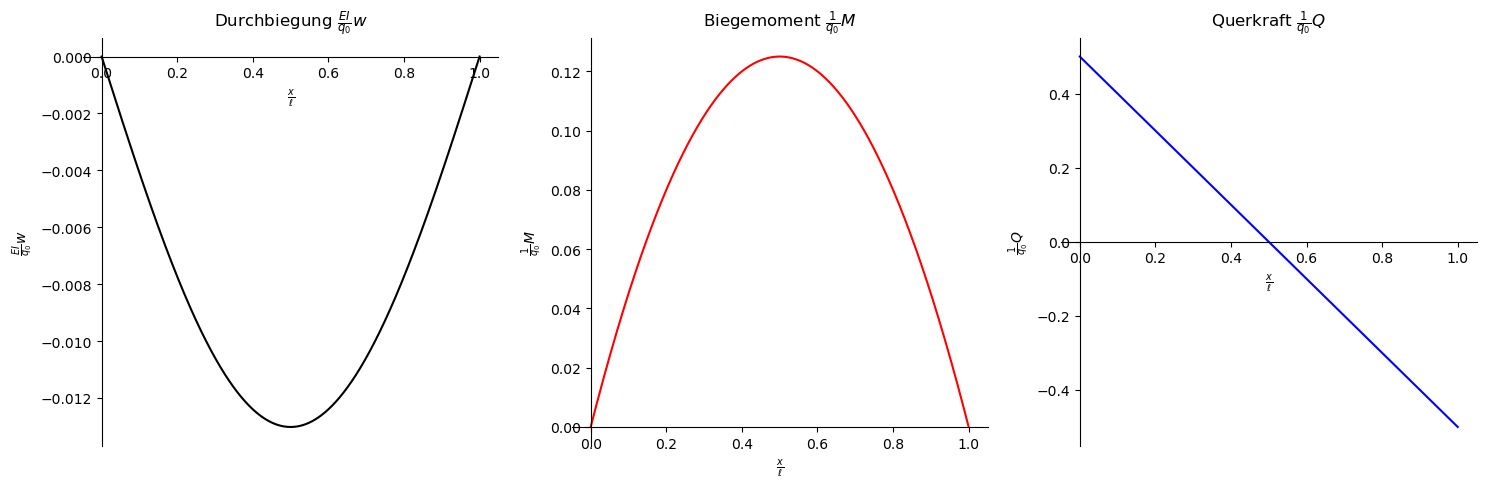

In [18]:
import sympy as sp
from sympy import Rational
from sympy import Eq
from sympy.plotting import plot, PlotGrid


x,EI,ell,q0,C_1,C_2,C_3,C_4 = sp.symbols('x,EI,ell,q0,C_1,C_2,C_3,C_4')

# Biegelinie
w = 1/EI*(Rational(1,24)*q0*x**4 +Rational(1,6)*C_1*x**3+Rational(1,2)*C_2*x**2+C_3*x+C_4)

# Bestimmung der Integrationskonstanten
eq1 = Eq(w.subs(x,0),0)
eq2 = Eq(w.subs(x,ell),0)
eq3 = Eq(-w.diff(x,2).subs(x,0),0)
eq4 = Eq(-w.diff(x,2).subs(x,ell),0)
solution = sp.solve((eq1,eq2,eq3,eq4),(C_1,C_2,C_3,C_4))
wfun = w.subs(solution)
Mfun = -wfun.diff(x,2)
Qfun = -wfun.diff(x,3)

# Plot der Biegelinie und Schnittgrößen
wp = w.subs(solution).subs({"ell":1,"q0":1,"EI":1})
M = -wp.diff(x,2)
Q = -wp.diff(x,3)

p1= plot(-wp,(x,0,1),title=r'Durchbiegung $\frac{EI}{q_0} w$',show=False,xlabel=r'$\frac{x}{\ell}$',ylabel=r'$\frac{EI}{q_0} w$',line_color='black')
p2= plot(M,(x,0,1),title=r'Biegemoment $\frac{1}{q_0} M$',show=False,xlabel=r'$\frac{x}{\ell}$',ylabel=r'$\frac{1}{q_0}M$',line_color='red')
p3= plot(Q,(x,0,1),title=r'Querkraft $\frac{1}{q_0}Q$',show=False,xlabel=r'$\frac{x}{\ell}$',ylabel=r'$\frac{1}{q_0}Q$',line_color='blue')


PlotGrid(1,3,p1,p2,p3,size=(15,5));

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

# Lösung mit der FEM

In [19]:
toggle

In [20]:
from BalkenFEM import BalkenFEM
import numpy as np

numnp = 6 # Anzahl der Knoten im System
numel = numnp -1 # Anzahl der Elemente im System
length = 8000 # Länge des Balkens in mm
q0 = -10 # N/mm


# Erzeugen des FE-Objektes
Lastfall = BalkenFEM(numnp=numnp,numel=numel)

# Definiere die Koordinaten der beiden Randknoten
X1 = np.array([0.0,0.0]) #mm
X2 = np.array([length,0.0]) #mm

# Generate interpolation points
t = np.linspace(0, 1, numnp)
X = X1 + t[:, np.newaxis] * (X2 - X1)
print(f"Coordinates of the nodes: \n{X}") 
Lastfall.setNodalCoords(X)

Coordinates of the nodes: 
[[   0.    0.]
 [1600.    0.]
 [3200.    0.]
 [4800.    0.]
 [6400.    0.]
 [8000.    0.]]


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

# Lösung mit der FEM

In [21]:
toggle

In [22]:
# Generate Elements
IX = np.column_stack((np.arange(0, numnp-1), np.arange(1, numnp)))
print(f"Connectivity table: \n{IX}")

Lastfall.setElements(IX)

# Material properties and cross section
Emod = 210000 # MPa
sma = 77.67*10**4 # mm^4
Ilist = [sma for i in range(numel)]
Elist = [Emod for i in range(numel)]

Lastfall.setElementData(Elist, Ilist)

Connectivity table: 
[[0 1]
 [1 2]
 [2 3]
 [3 4]
 [4 5]]


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Plot Balken FEM

In [23]:
toggle

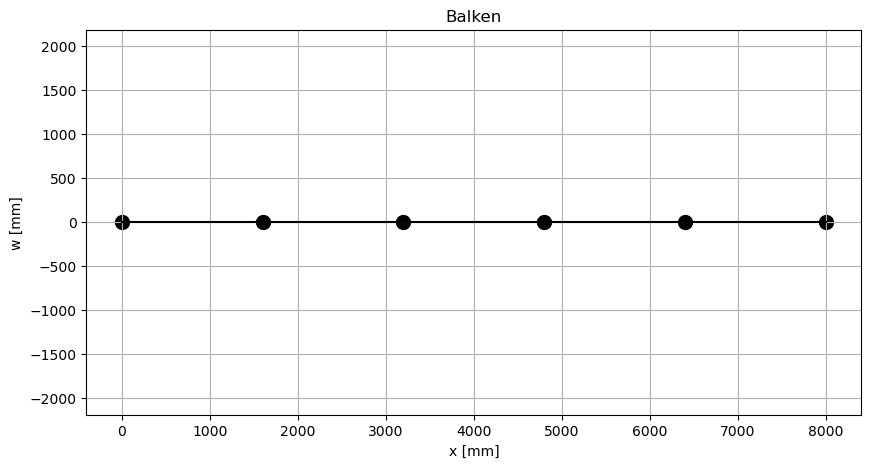

In [24]:
import matplotlib.pyplot as plt
wanalytisch = sp.lambdify(x,wfun.subs({"EI":Emod*sma,"q0":q0,"ell":length}),"numpy")

def plotBalken(X,q=None,fval1=None,u=None):
    fix,ax = plt.subplots(figsize=(10,5))
    if u is not None:
        ax.plot(X[:,0],X[:,1]+u,c='b')
        xline = np.linspace(0,length,100)
        wanalytisch = sp.lambdify(x,wfun.subs({"EI":Emod*sma,"q0":q0,"ell":length}),"numpy")
        ax.plot(xline,wanalytisch(xline),'b--')
        ax.legend(["w - FEM","w - analytisch"])
    ax.scatter(X[:,0],X[:,1],c='k',s=100)
    ax.plot(X[:,0],X[:,1],c='k')
    if q is not None:
        ax.quiver(X[:,0], X[:,1],  [0 for i in range(numnp)],q,color='red')
    if fval1 is not None:
        ax.quiver(X[:,0], X[:,1],  [0 for i in range(numnp)],fval1,color='red')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('w [mm]')
    ax.set_title('Balken')
    ax.grid(True)
    
    plt.axis('equal')
    plt.show()

plotBalken(X)

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Aufbringen der Randbedingungen

In [25]:
toggle

In [26]:
# Dirichlet Randbedingungen (Verschiebung)
dnodes = [0, numnp-1] # Liste der Knoten an denen Randbedingungen aufgebracht werden
ddir = [0,0] # (Knoten, Richtung) Liste in welcher Richtung ein Knoten festgehalten wird
dval = [0,0] # (Knoten, Wert) Liste, welcher Verschiebungswert am Knoten vorgeschrieben wird

Lastfall.setDirichletBoundaryCondition(dnodes,ddir,dval)

# Neumann Randbedingungen (Kraft)
fnodes = [i for i in range(numnp)] # Liste der Knoten auf denen Kräfte aufgebracht werden (potenziell alle)
mnodes = [i for i in range(numnp)] # Liste der Knoten auf denen Momente aufgebracht werden (potenziell alle)
fdir1 = [0 for i in range(numnp)]  # (Knoten, Richtung) Kraft
mdir2 = [1 for i in range(numnp)]  # (Knoten, Richtung) Moment
fval1 = [0 for i in range(numnp)]  # (Knoten, Kraftwert) 
mval2 = [0 for i in range(numnp)]  # (Knoten, Momentwert)

Lastfall.setExternalForces(fnodes+mnodes,fdir1+mdir2,fval1+mval2)

# Verteilte Lasten

q=q0*np.ones((numnp,1))
Lastfall.setDistributedLoads(q)

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Lösen des FE-Problems

In [27]:
toggle

In [28]:
Lastfall.assembleGlobalMatrix2D() # Assemblierung der Elementbeiträge
Lastfall.solveSystem() # Lösen des Gleichungssystems

/home/steffen/apps/anaconda3/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/home/steffen/apps/anaconda3/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


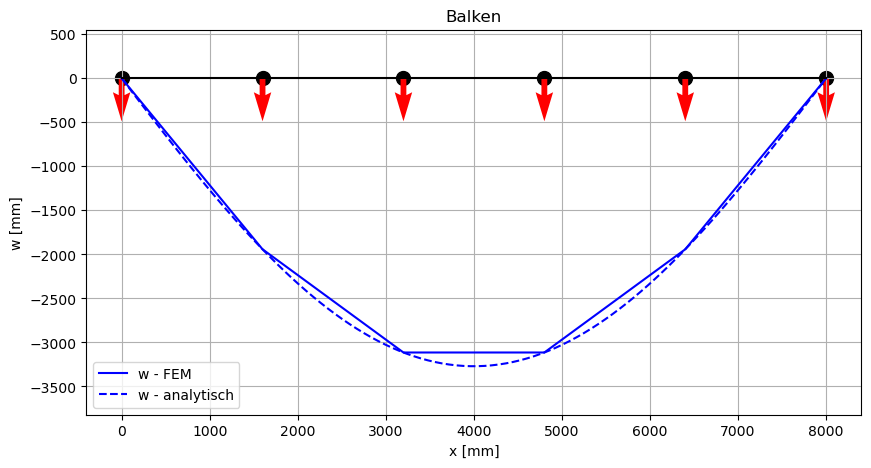

In [29]:
plotBalken(X,q,fval1,Lastfall.dof[:,0])

In [30]:
wa = wanalytisch(4000)
wFEM = Lastfall.getDisplacement(4000)
error = (wa-wFEM)/wa*100

print(f"Durchbiegung analytisch: {wa}")
print(f"Durchbiegung FEM: {wFEM}")
print(f"Fehler: {error}%")

Durchbiegung analytisch: -3269.8371825448057
Durchbiegung FEM: -3268.790834646392
Fehler: 0.03199999999998483%


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

# Bestimmung der Schnittlasten

### Schnittmoment

In [31]:
toggle

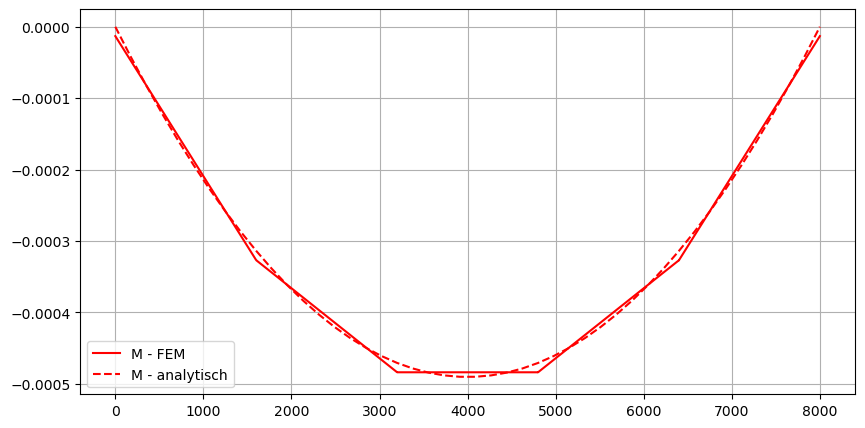

In [32]:
xm,M = Lastfall.computeMoment(n=10)
Manalytisch  = sp.lambdify(x,Mfun.subs({"EI":Emod*sma,"q0":q0,"ell":length}),"numpy")

def plotMoment(x,M):
    fix,ax = plt.subplots(figsize=(10,5))
    ax.plot(x,M,'r')
    ax.plot(x,Manalytisch(x),'r--')
    ax.legend(["M - FEM","M - analytisch"])
    ax.grid(True)

plotMoment(xm,M)

In [33]:
Ma = Manalytisch(4000)
MFEM = np.min(M)
error = (Ma-MFEM)/Ma*100

print(f"Biegemoment analytisch: {Ma}")
print(f"Biegemoment FEM: {MFEM}")
print(f"Fehler: {error}%")

Biegemoment analytisch: -0.0004904755773817184
Biegemoment FEM: -0.00048393590301663326
Fehler: 1.333333333332422%


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

### Schnittgröße: Querkraft

In [34]:
toggle

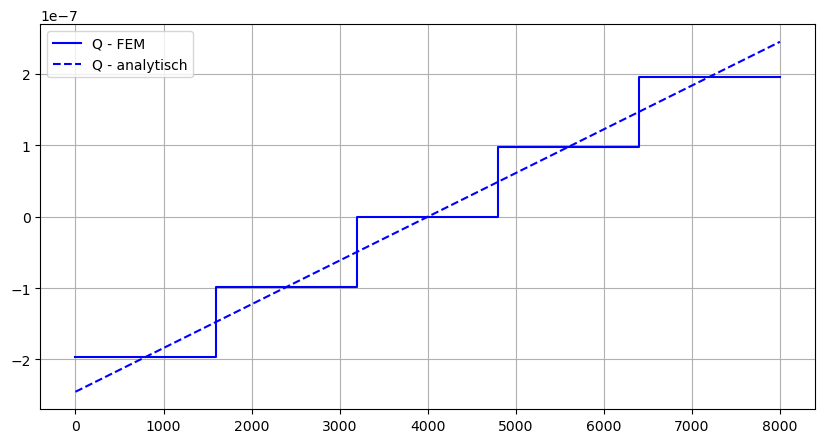

In [35]:
xm,Q = Lastfall.computeQuerkraft(n=10)
Qanalytisch  = sp.lambdify(x,Qfun.subs({"EI":Emod*sma,"q0":q0,"ell":length}),"numpy")


def plotQuerkraft(x,Q):
    fix,ax = plt.subplots(figsize=(10,5))
    ax.plot(x,Q,'b')
    ax.plot(x,Qanalytisch(x),'b--')
    ax.legend(["Q - FEM","Q - analytisch"])
    ax.grid(True)
    
plotQuerkraft(xm,Q)

In [36]:
Qa = Qanalytisch(0)
QFEM = np.min(Q)
error = (Qa-QFEM)/Qa*100

print(f"Querkraft analytisch: {Qa}")
print(f"Querkraft FEM: {QFEM}")
print(f"Fehler: {error}%")

Querkraft analytisch: -2.45237788690859e-07
Querkraft FEM: -1.9619023095268617e-07
Fehler: 20.000000000000416%


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

# Konvergenzstudie

In [37]:
def setUpProblem(numnp):
    numel = numnp -1
    length = 8000

    Lastfall = BalkenFEM(numnp=numnp,numel=numel)

    X1 = np.array([0.0,0.0])     #mm
    X2 = np.array([length,0.0]) #mm


    # Generate interpolation points
    t = np.linspace(0, 1, numnp)
    X = X1 + t[:, np.newaxis] * (X2 - X1)
    # print(f"Coordinates of the nodes: \n{X}") 

    Lastfall.setNodalCoords(X)

    # Generate Elements
    IX = np.column_stack((np.arange(0, numnp-1), np.arange(1, numnp)))
    # print(f"Connectivity table: \n{IX}")

    Lastfall.setElements(IX)

    # Material properties and cross section
    Emod = 210000 # MPa
    sma = 77.67*10**4 # mm^4
    Ilist = [sma for i in range(numel)]
    Elist = [Emod for i in range(numel)]

    Lastfall.setElementData(Elist, Ilist)

    # Dirichlet Randbedingungen (Verschiebung)
    dnodes = [0, numnp-1]
    ddir = [0,0]
    dval = [0,0]


    
    Lastfall.setDirichletBoundaryCondition(dnodes,ddir,dval)

    # Neumann Randbedingungen (Kraft)
    fnodes = [i for i in range(numnp)] # forces
    mnodes = [i for i in range(numnp)] # moments
    fdir1 = [0 for i in range(numnp)] 
    mdir2 = [1 for i in range(numnp)] 
    fval1 = [0 for i in range(numnp)]
    mval2 = [0 for i in range(numnp)]
    q0 = -10 # N/mm

    Lastfall.setExternalForces(fnodes+mnodes,fdir1+mdir2,fval1+mval2)

    # Verteilte Lasten

    q=q0*np.ones((numnp,1))
    Lastfall.setDistributedLoads(q)


    Lastfall.assembleGlobalMatrix2D()
    Lastfall.solveSystem()

    xm,Q = Lastfall.computeQuerkraft(n=3)
    xm,M = Lastfall.computeMoment(n=3)


    return np.min(Q),np.min(M),Lastfall

In [38]:
toggle

In [39]:
maxpoints = 202
nstud = 51

npoints =  np.linspace(2,maxpoints,nstud)

QFEM = np.zeros((nstud,))
MFEM = np.zeros((nstud,))
ErrorM= np.zeros((nstud,))
ErrorQ= np.zeros((nstud,))

for i,p in enumerate(npoints):
    
    QQ,MM,LC=setUpProblem(int(p))
    QFEM[i]=QQ
    MFEM[i]=MM
    ErrorQ[i] = (Qa-QFEM[i])/Qa*100
    ErrorM[i] = (Ma-MFEM[i])/Ma*100

df = pd.DataFrame({"M":MFEM,"error M":ErrorM,"Q":QFEM,"error Q":ErrorQ},index=npoints)
display(df)

,M,error M,Q,error Q
2.0,-0.000327,33.333333,-0.000000e+00,100.000000
6.0,-0.000484,1.333333,-1.961902e-07,20.000000
10.0,-0.000488,0.411523,-2.179891e-07,11.111111
14.0,-0.000490,0.197239,-2.263733e-07,7.692308
18.0,-0.000490,0.115340,-2.308120e-07,5.882353
22.0,-0.000490,0.075586,-2.335598e-07,4.761905
26.0,-0.000490,0.053333,-2.354283e-07,4.000000
30.0,-0.000490,0.039635,-2.367813e-07,3.448276
34.0,-0.000490,0.030609,-2.378063e-07,3.030303
38.0,-0.000490,0.024349,-2.386097e-07,2.702703


<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Visualisierung der Konvergenz

In [40]:
toggle

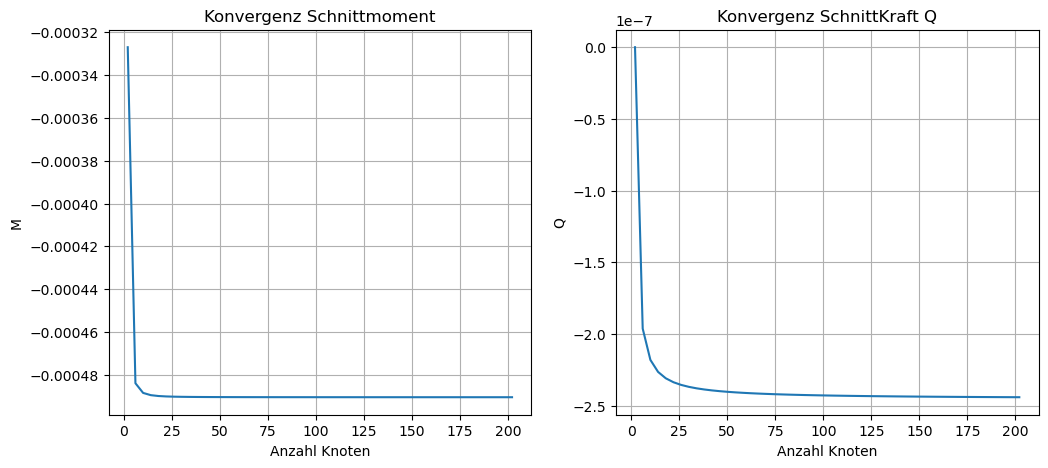

In [41]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(df.index,df["M"])
ax[0].set_title("Konvergenz Schnittmoment")
ax[0].set_xlabel("Anzahl Knoten")
ax[0].set_ylabel("M")
ax[0].grid(True)
ax[1].plot(df.index,df["Q"])
ax[1].set_title("Konvergenz SchnittKraft Q")
ax[1].set_xlabel("Anzahl Knoten")
ax[1].set_ylabel("Q")
ax[1].grid(True)

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

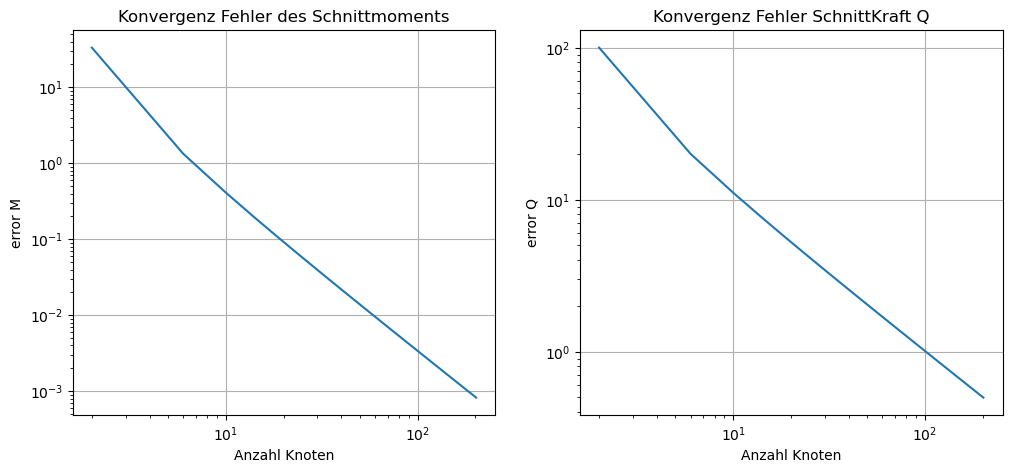

In [42]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(df.index,df["error M"])
ax[0].set_title("Konvergenz Fehler des Schnittmoments")
ax[0].set_xlabel("Anzahl Knoten")
ax[0].set_ylabel("error M")
ax[0].set_yscale("log")  # Set y-axis to logarithmic scale
ax[0].set_xscale("log")  # Set x-axis to logarithmic scale
ax[0].grid(True)
ax[1].plot(df.index,df["error Q"])
ax[1].set_title("Konvergenz Fehler SchnittKraft Q")
ax[1].set_xlabel("Anzahl Knoten")
ax[1].set_ylabel("error Q")
ax[1].set_yscale("log")  # Set y-axis to logarithmic scale
ax[1].set_xscale("log")  # Set x-axis to logarithmic scale
ax[1].grid(True)

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>

## Analyse der Steifigkeitsmatrix

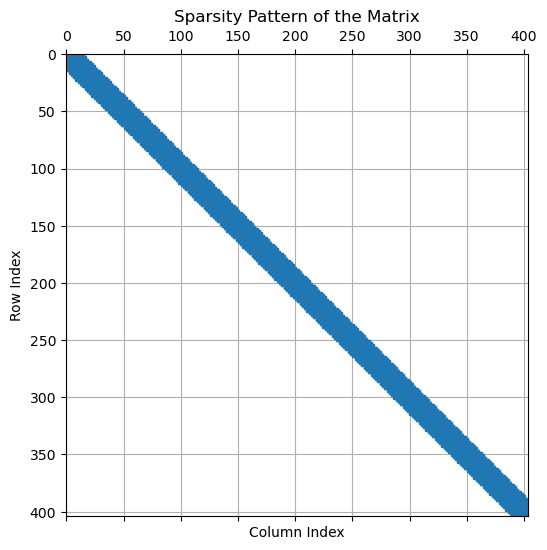

In [43]:
matrix = LC.Kges
plt.figure(figsize=(6, 6))
plt.spy(matrix, markersize=10)  # You can adjust the markersize as needed
plt.title('Sparsity Pattern of the Matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid()
plt.show()

<div class='footer'>Vorlesung_03_Balken_FEM | FEM für Strukturelemente | 20-10-2025</div>